In [11]:
%pip install scikit-learn pandas matplotlib numpy

Note: you may need to restart the kernel to use updated packages.


# **Arvores de decisao**
 
Arvores de decisao é um tipo de algoritmo de ML que pode ser usado tanto para regressao quanto classificacao. Essas arvores sao componentes essenciais de modelos muito bons como RandomForest e XGBoost.

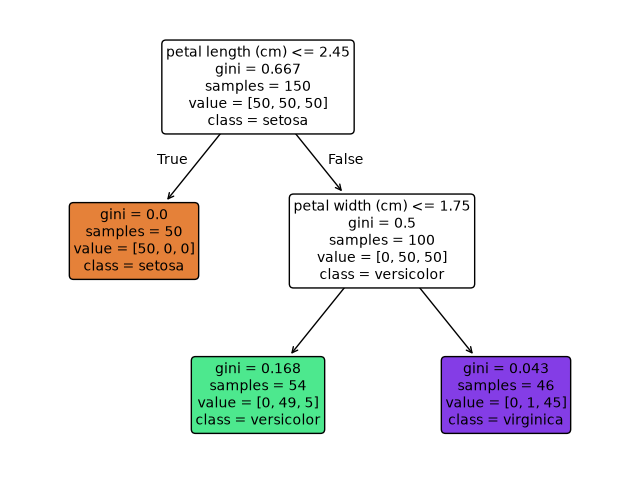

In [12]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

iris = load_iris(as_frame=True)
X_iris = iris['data']
Y_iris = iris['target']

tree_classifier = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_classifier.fit(X_iris, Y_iris)

plt.figure(figsize=(8, 6))
plot_tree(
    tree_classifier,
    feature_names=X_iris.columns,
    class_names=iris['target_names'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.show()

## **Inferencia** 

Em arvores de decisao existem 2 tipos de nós:

- **split/decision nodes:** Representam nós com *decisoes aprendidas com base nos dados de treino*. Dentro desses nós existe alguma regra (regra binária para arvores binárias mas existem algortimos que aceitam arvores nao binárias) baseada nos dados e alguma coluna, como por exemplo, comprimento da petala <= 2.45 .
- **leaf node:** Folhas do grafo que de fato fazem a predicao e decidem o output.

O processo de inferencia *comeca na raiz da arvore e de acordo com os dados do X que estamos inferindo vamos deslocar pelos nós da arvore ate chegar em uma folha e a predicao ser feita*. Por exemplo, se fizermos inferencia para uma flor com comprimento de petala menor que 2.45 vamos nos deslocar para o nó da esquerda que é uma folha e essa instancia de flor sera classificada como setosa.

Detalhe, por essa inferencia ser feita através de decisoes sem ponderacao de features a* escala das features nao afeta em nada a predicao*.

Cada nó na arvore da imagem é composto por:

- **class:** representa a classe que o nó classificaria as instancias caso ele seja uma folha (a com maior probabilidade, ou seja, mais frequente no nó)
- **value:** representa quanto de cada classe existe no nó
- **samples:** representa quantas instancias chegaram naquele nó durante o 
- **gini/entropia:** representa a métrica de qualidade daquele nó (como se fosse uma loss), essa métrica diz o quao indeciso aquele nó esta com base no estado do nó. As métricas mais comuns sao Impureza de Gini e entropia.

### **Interpretacao de modelo**

- **Whitebox:** modelo é transparente por natureza, você consegue entender como ele chega à decisão só de olhar sua estrutura interna. É uma propriedade intrínseca do modelo como arvores de decisao e regressao linear.
- **Blackbox:** Humanamente muito dificil ou impossivel entender como o modelo chegou naquela predicao especifica. Geralmente metodos de explicabilidade sao usados para mitigar.

## **Estimar probabilidade**

A arvore nao apenas faz predicao mas também consegue dizer a probabilidade dessa predicao. *A distribuicao de instancias que cairam naquela folha durante o treino fica armazenado e usando ela é possivel calcular a probabilidade de cada classe naquela folha especifica*. Por exemplo, se 10 instancias durante o treino terminaram naquela folha e temos 3 de uma classe e 7 de outra entao suas respectivas probabilidades sao 30% e 70%. 

- Uma limitacao aqui é que *essa probabilidade é independente das features  mas dependente das regras criadas*, ou seja, **instancias muito diferentes na mesma folha vao ter mesmo probabilidade**. Exemplo: se [1,1.5] e [3,1.5] cair na mesma folha nao interessa se a primeira feature é muito diferente... a probabilidade será a mesma

In [13]:
proba = tree_classifier.predict_proba([[1,3,4,5]])
print(proba)

proba2 = tree_classifier.predict_proba([[1,15,4,5]])
print(proba2)

[[0.         0.02173913 0.97826087]]
[[0.         0.02173913 0.97826087]]


/home/luis/Documents/Personal/study/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/home/luis/Documents/Personal/study/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## **Treino**

O treino pode acontecer usando varios algoritmos mas os principais sao o Classification and Regression Tree (CART), implementado no sklearn e que *gera apenas arvores binárias* mas existem outros algoritmos que a arvore nao é mais binária como o ID3.

### **CART**

O algoritmo *recebe um conjunto/subconjunto de instancias de treino e tenta dividir esse conjunto em 2 grupos*. Para dividir as instancias é usado uma feature *k e um limiar t_k dessa feature*. Por exemplo no nó da raiz dividimos o espaco usando a feature k = comprimento da petala e o limiar tk = 2.45 cm.

O problema aqui é como escolher qual feature e limiar dentre as infinitas combinacoes. A ideia é escolher dentre pares (k,t_k) o que *minimiza a funcao de custo J que é a média da pureza dos conjuntos ponderada pelo tamanho dos subconjuntos*.

$$ (k, t_k) = \frac{m_{left} \cdot G_{left} + m_{right} \cdot G_{right}}{m} $$

Em que:
- **G left/right** sao as purezas dos 2 subconjuntos 
- **m left/right** o tamanho deles 
- **m** = m_left + m_right.

A ideia de ser ponderada é *garantir que conjuntos puros maiores tenhama mais peso na Loss que conjuntos pequenos impuros*, isso pode acontecer se o k e k_t dividirem os dados de forma muito desbalanceada. Por exemplo, um conjunto de tamanho 2 super impuro e um de tamanho 98 muito puro... sem a ponderacao a loss será alta quando deveria ser baixa.

O processo é *recursivo* entao depois de encontrar a melhor primeira divisão, o CART repete exatamente o *mesmo processo dentro de cada subconjunto criado*, como se cada um fosse um novo problema pequeno. E depois dentro dos sub-subconjuntos. Ele para quando:

- Atinge a *profundidade máxima* (max_depth)
- Não consegue mais achar uma *divisão que reduza a impureza*
- Outros critérios de parada vindos de hyperparametros são atingidos 

#### **Quais pares de testar ?**

Como o numero de (k,t_k) pode crescer infinitamente por causa do limiar a ideia aqui é testar todas as features com *limiares calculados com base no conjunto desse nó*. Se o conjunto tem 3 instancias com features [1,2,3] os limiares testados para essa feature serao [1.5,2.5], ou seja os pontos medios entre os valores da feature ordenadas.

#### **Funcoes de pureza** 

Ambas são formas de medir o quão *"misturado" (impuro) está um conjunto de dados em relação às classes* que ele contém. Quanto mais próximo de zero, mais puro (homogêneo) é o conjunto, ou seja, mais ele contém instâncias de uma única classe.

- **Impureza de Gini:** O somatório de probabilidade só vai ser 1 quando todas as classes no nó forem iguais, ou seja, a impureza só é 0 quando a probabilidade de uma classe/valor ali dentro for 1.

$$ G_i = 1 - \sum_{k=1}^{n} p_{i,k}^2 $$

- **Entropia:** Entropia de uma distribuicao de probabilidade é alta quando existe incerteza, ou seja, todos os valores/classes tem probabilidade parecida. Isso ajuda aqui pois quando a distribuicao de probabilidade em um nó é concentrada em apenas um valor/classe a entropia vai ser 0.

$$ H_i = -\sum_{\substack{k=1 \\ p_{i,k} \neq 0}}^{n} p_{i,k} \log_2\left(p_{i,k}\right) $$


No fim ambas na maioria dos casos *geram resultados muito parecidos* porém como na Gini nao é necessário calcualar log, ela é usada como padrao pois é *mais rapida no treino*. Entropia costuma *gerar arvores um pouco mais balanceadas* fazendo a inferencia do caso médio ser um pouco mais rapida mas nada que justifique.

#### **Complexidade** 

O CART implementado toma decisoes de divisao locais sem pensar no futuro, ou seja, é um **algortimo guloso** que pega sempre o melhor atual e nunca volta atras na sua decisao. 

- A **complexidade de inferencia** dele consiste em descer da raiz da arvore ate alguma folha, ou seja, cresce com a altura dessa arvore que é **O(log2(m))** caso a arvore binária esteja balanceada. 
- A **complexidade de treino** é dominada por uma operacao inicial: para conseguir todos os t_k (valores medios/splits) possiveis de uma feature precisamos ordenar todas as *m* linhas daquela feature e isso da *O(m x log(m))*, como temos que fazer isso para todas as *n* features a complexidade vai para *O(n x m x log(m))*.

Consequentemente ele quase nunca vai chegar na solucao otima... um CART que chega na *solucao otima seria um CART que testa todas as arvores possiveis* de serem geradas que gera uma complexidade **exponencial**, que é intratavel mesmo usando tecnicas de programacao Dinamica. 

#### **Hyperparametros de regularizacao**

Diferente de modelos lineares que assumem que os dados sao lineares, arvores de decisao fazem muito poucas premissas sobre os dados de treino e isso da muita liberdade para ela se adaptar a distribuicao. Arvores nao tem um numero fixo de parametros (graus de liberdade limitado) como redes neurais e modelos lineares, isso significa que ela pode criar quantos parametros (divisoes) ela quiser se nao for limitada. Uma arvore se dividir ao ponto de existe uma folha para cada instancia de treino sendo esse o maior overfitting possivel. 

Para evitar esse overfitting limitando os graus de liberdade da arvore (quanto ela pode crescer) usando hyperparametros de regularizacao:
- **max_depth:** Limita a profundidade da arvore evitando divisoes desnecessárias e aumentando a interpretabilidade
- **max_features:** Maximo de features que vao ser testadas nos pares (k, k_t), isso limita as combinacoes para datasets com muitas features mas deixa o algoritmo mais guloso ainda
- **max_leaf_nodes:** Maximo de folhas que podem ser geradas
- **min_samples_split:** Minimo de dados no subconjunto para ser dividido evitando divisoes pequenas como dividir 2 instancias em 2 nós de 1 instancia
- **min_samples_leaf:** Minimo de dados em uma folha para divisao acontecer (por exemplo podemos ter o minimo para fazer o split mas esse split gerar um nó com 1 instancia só, a divisao é bloqueada), util para datasets pequenos
- **min_impurity_decrease:** Reducao minima na pureza para compensar fazer split nos dados (daquelas combinacoes (k, k_t) se nenhuma reduzir a loss mais que esse paramtro nao é dividido)
- **ccp_alpha:** A ideia aqui nao é limitar o crescimento mas sim fazer pruning depois que a arvore estiver pronta, removendo subarvores apartir de uma métrica de complexidade em que quanto mais folhas mais complexo. 
    - alpha mais alto = mais pruning 
    - alpha zero é o padrao = sem pruning
    - O pruning pode acontecer usando testes estatisticos para ver se a reducao na pureza é real ou ruido


## **Decision Tree para regressao**

O algoritmo CART pode ser usado para regressao com algumas alteracoes 

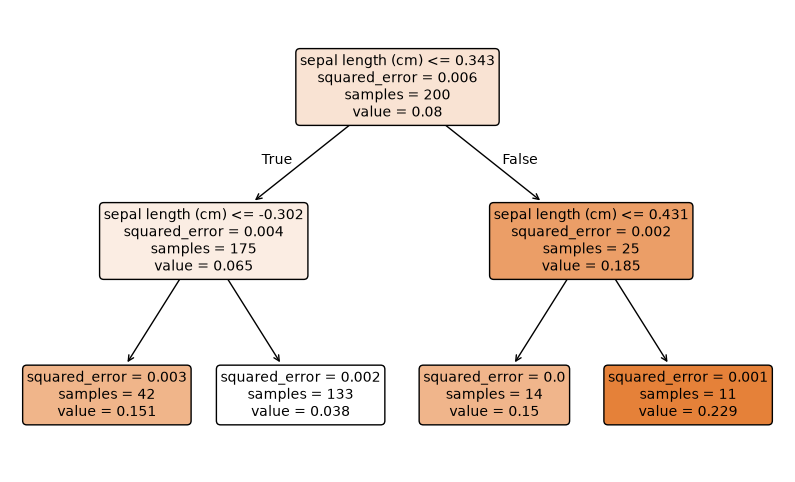

In [14]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor

rand_numb_generator = np.random.default_rng(seed=42)

X_quad = rand_numb_generator.random((200,1)) - 0.5
y_quad = X_quad ** 2 + 0.025 * rand_numb_generator.standard_normal((200, 1))


tree_regressor = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_regressor.fit(X_quad, y_quad)

plt.figure(figsize=(10, 6))
plot_tree(
    tree_regressor,
    feature_names=X_iris.columns,
    class_names=iris['target_names'],
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.show()


### **Inferencia**

Agora 2 campos dos nós mudaram:

- value nao é mais a distribuicao de classes em um nó e sim a *media dos valores daquele nó*. Essa média também substitui o campo classe pois essa *média é a predicao*.
- ao invés de pureza do nó olhamos para o *erro MSE da regressao*

Para a predicao, descemos na arvore do mesmo jeito mas usamos de predicao a media dos n valores que estao nas folhas,ou seja, todo mundo que cair na mesma folha tem a mesma predicao. Isso faz com que a árvore nunca preveja fora do range [min, max] visto no treino.

### **Treino**

Agora nao otimizamos para minimizar a pureza dos nós mas sim para otimzar o MSE medio ponderado pelo tamanho do subconjunto.

$$J(k, t_k) = \frac{m_{left}}{m} \cdot \text{MSE}_{left} + \frac{m_{right}}{m} \cdot \text{MSE}_{right}$$

Assim como os classificadores o overfitting aqui é muito facil e é necessário ter os mesmos cuidados.


## **Caracteristicas de Arvore de Decisao e pontos negativos**

### **Sensibilidade ao eixo de separacao**

As margens de decisao de arvores sao apenas retas e sempre ortogonais entre sim devido as decisoes binárias de cada nó. Isso faz com que seja relativamente simples separar classes que tem uma divisao quase ortogonal mas complexo para classes que a divisao é uma diagonal, parabola ou curvas mais complexas. Para se ajustar a essas curvas a arvore terá que dividir o espaco muitas vezes e varias delas desnecessáriamente. Uma forma de mitigar que as vezes funciona é reducao de dimensionalidade com PCA que tende a tornar as separacoes mais comportadas.

### **Lidam com missing values nativamente**

O CART original lida com isso nativamente usando divisoes substitutas, que funciona da seguinte maneira: Ao escolher o melhor par (k, k_t) também deixamos registrado pares parecidos que usam outras features. Se a feature principal estiver faltando usamos os parecidos. Se todas estao faltando mandamos para o conjunto com mais instancias (maioria).

### **Alta variancia**

A arvore gerada pode mudar significativamente com pequenas alteracoes nos dados ou nos hyperparametros... nao apenas isso, se max_features < numero de features, o sklearn escolhe features para testar aleatoriamente entao mesmo com os mesmo dados e hyperparametros se a seed nao for setada os resultados nao serao os mesmos.

### **Viés a favor de features com muitas categorias**
 
Quando uma feature é categorica a decisao nao é mais "maior que algo ?" e sim "é de um grupo de categorias ?", o problema que essas *combinacoes de categorias crescem 2^(n_categorias) - 1* e isso aumenta muito a chance de achar algum ruido dos dados que parece bom.

## **Perguntas:**

1. Profundidade aproximada com 1 milhão de instâncias ?

    - se a arvore estiver balanceada será algo como: log2​(1.000.000) ≈ 19,93

2. Gini de um filho pode ser maior que o do pai ?

    - sim, pois a divisao escolhida será sempre a media ponderada do Gini dos 2 filhos e isso permite que se um filho tiver um Gini extremamente baixo e o outro alto, ele pode ser escolhido. Mas na média dos casos a impureza dos filhos vai ser menor pois é o que esta sendo otimizado.

3. Overfitting → diminuir max_depth?

    - sim, é uma boa ideia pois reduz a complexidade do modelo aumentando a regularizacao. A arvore terá menos liberdade para decorar os dados.

4. Underfitting → escalar as features ajuda?

    - Nao, modelos de arvore sao insensiveis a escala. A solucao seria dar mais liberdade ao modelo aumentando talvez o max_depth

5. Implemente um Random Forest

In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
from scipy.stats import mode

X_moons, y_moons = make_moons(n_samples=10000, noise=0.4)

X_train, X_test, y_train, y_test = train_test_split(
    X_moons, y_moons, test_size=0.2, random_state=42, stratify=y_moons
)

param_grid = {"max_leaf_nodes": [5, 10, 20, 30, 50, 100, 200, 500, None]}
dt = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(dt, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)
print("Best params:", grid.best_params_, "Best CV accuracy:", grid.best_score_) 


best_dt = grid.best_estimator_
best_dt.fit(X_train, y_train)
y_pred = best_dt.predict(X_test)
acc_full = accuracy_score(y_test, y_pred)
print("Test accuracy (DecisionTree on full training set): {:.4f}".format(acc_full))

# 1000 trees trained on random subsets of size 100
n_trees = 1000
subset_size = 100
ss = ShuffleSplit(n_splits=n_trees, train_size=subset_size, random_state=42)

small_tree_accuracies = []
preds = []

for i, (train_idx, _) in enumerate(ss.split(X_train)):
    X_sub = X_train[train_idx]
    y_sub = y_train[train_idx]
    # construct classifier with same hyperparams (handle None)
    params = grid.best_params_.copy()
    if params.get('max_leaf_nodes') is None:
        clf = DecisionTreeClassifier(random_state=42 + i)
    else:
        clf = DecisionTreeClassifier(max_leaf_nodes=params['max_leaf_nodes'], random_state=42 + i)
    clf.fit(X_sub, y_sub)
    y_t = clf.predict(X_test)
    preds.append(y_t)
    small_tree_accuracies.append(accuracy_score(y_test, y_t))

small_mean = np.mean(small_tree_accuracies)
print("Average accuracy of small trees: {:.4f} (std {:.4f})".format(small_mean, np.std(small_tree_accuracies)))

# Majority vote across the 1000 trees
preds = np.array(preds)  # shape (n_trees, n_test)
majority_votes = mode(preds, axis=0).mode
ensemble_acc = accuracy_score(y_test, majority_votes)
print("Ensemble (majority vote) accuracy: {:.4f}".format(ensemble_acc))

print('\nSummary:')
print(' - DecisionTree (full training set) test acc: {:.4f}'.format(acc_full))
print(' - Mean small-tree acc: {:.4f}'.format(small_mean))
print(' - Ensemble acc: {:.4f}'.format(ensemble_acc))


Best params: {'max_leaf_nodes': 5} Best CV accuracy: 0.8546249999999999
Test accuracy (DecisionTree on full training set): 0.8545
Average accuracy of small trees: 0.8221 (std 0.0292)
Ensemble (majority vote) accuracy: 0.8570

Summary:
 - DecisionTree (full training set) test acc: 0.8545
 - Mean small-tree acc: 0.8221
 - Ensemble acc: 0.8570
